In [ ]:
#CHECK FOR WORKING
import sys
import os

PROJECT_ROOT = os.path.abspath(r"..\..")
sys.path.append(PROJECT_ROOT)

from config import SITES, TIME_DIM

print("CONFIG LOADED ✔")
print(SITES)

CONFIG LOADED ✔
{'chile': {'name': 'Chile (ALMA region)', 'path': 'C:\\Users\\2021n\\Downloads\\era5_wind_data_analysis\\data\\raw\\chile\\chile_*.nc', 'lat': -23.029, 'lon': -67.755}, 'cerro_toco': {'name': 'Cerro Toco', 'path': 'C:\\Users\\2021n\\Downloads\\era5_wind_data_analysis\\data\\raw\\chile\\chile_*.nc', 'lat': -22.94, 'lon': -67.78}, 'hanle': {'name': 'Hanle', 'path': 'C:\\Users\\2021n\\Downloads\\era5_wind_data_analysis\\data\\raw\\HN Data Monthly\\india_*.nc', 'lat': 32.779, 'lon': 78.964}, 'nurbula': {'name': 'Nurbula Top', 'path': 'C:\\Users\\2021n\\Downloads\\era5_wind_data_analysis\\data\\raw\\HN Data Monthly\\india_*.nc', 'lat': 32.804, 'lon': 78.396}}


In [ ]:
#BEFORE EVERY PLOT
import sys
import os
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# allow config import from project root
PROJECT_ROOT = os.path.abspath(r"..\..")
sys.path.append(PROJECT_ROOT)

from config import SITES, VARIABLES, TIME_DIM

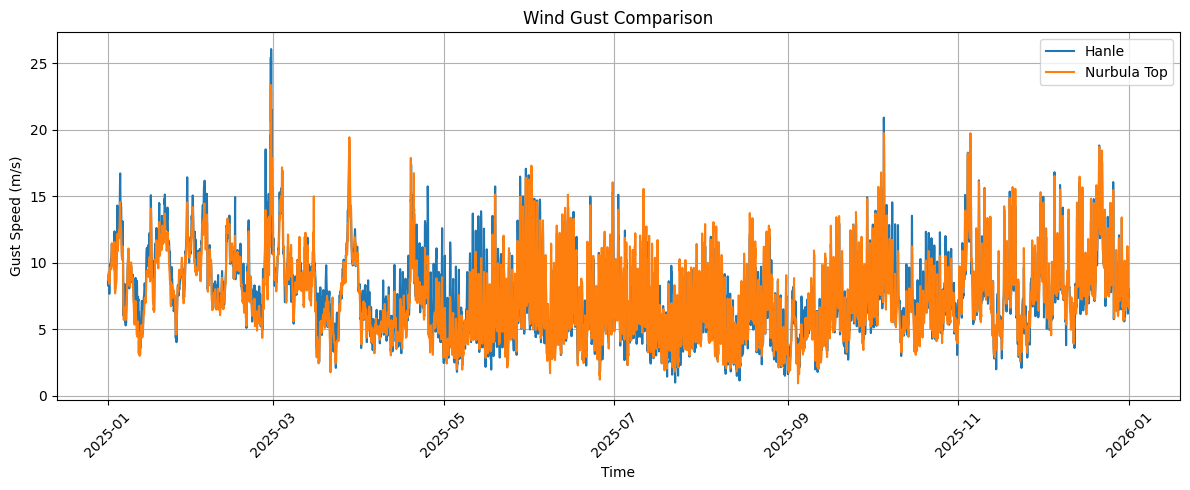

Max gust (site1): 26.065212
Max gust (site2): 23.360031
Points site1: 8760
Points site2: 8760


In [24]:

#WIND GUST COMPARISON PLOT

#CHANGE HERE
site1 = SITES["hanle"]
site2 = SITES["nurbula"]

# data
files = sorted(glob.glob(site1["path"]))
ds = xr.open_mfdataset(files, combine="by_coords")
ds = ds.sortby(TIME_DIM)
time = ds[TIME_DIM]

# var
gust_var = VARIABLES["gust"]

if gust_var not in ds:
    raise KeyError(f"{gust_var} not found in dataset")

gust = ds[gust_var]

# gridpoints
gust_s1 = gust.sel(
    latitude=site1["lat"],
    longitude=site1["lon"],
    method="nearest"
)

gust_s2 = gust.sel(
    latitude=site2["lat"],
    longitude=site2["lon"],
    method="nearest"
)

# clean
gust_vals_1 = gust_s1.values.flatten()
gust_vals_2 = gust_s2.values.flatten()

# plt
plt.figure(figsize=(12,5))

plt.plot(time, gust_vals_1, label=site1["name"])
plt.plot(time, gust_vals_2, label=site2["name"])

plt.title("Wind Gust Comparison")
plt.xlabel("Time")
plt.ylabel("Gust Speed (m/s)")

plt.legend()
plt.grid()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#syntax
print("Max gust (site1):", np.max(gust_vals_1))
print("Max gust (site2):", np.max(gust_vals_2))
print("Points site1:", len(gust_vals_1))
print("Points site2:", len(gust_vals_2))

Files found: 24
Saved figure → ..\..\data\exports\Chile_(ALMA_region)_wind_2001_01-02_combined.png


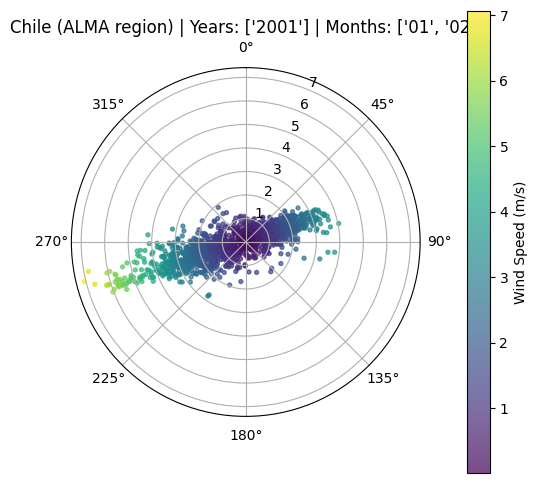

In [ ]:

# =====================================================
# SETUP (RUN ONCE PER NOTEBOOK)
# =====================================================
import sys
import os
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from config import SITES, TIME_DIM

PROJECT_ROOT = os.path.abspath(r"..\..")
sys.path.append(PROJECT_ROOT)

# =====================================================
# CONFIG (YOU CONTROL EVERYTHING HERE)
# =====================================================

site = SITES["chile"]     # change site here

selected_years = ["2001"]     # or ["all"]
selected_months = ["01", "02"] # or ["all"]

plot_mode = "combined"  
# options: "combined", "separate"

# =====================================================
# LOAD DATA
# =====================================================
files = sorted(glob.glob(site["path"]))

print("Files found:", len(files))

if len(files) == 0:
    raise ValueError("No files found. Check config path.")

ds = xr.open_mfdataset(files, combine="by_coords")
ds = ds.sortby(TIME_DIM)

time = ds[TIME_DIM].values

# =====================================================
# FILTER TIME (YEAR + MONTH)
# =====================================================
mask = []

for t in time:
    year = str(t)[:4]
    month = str(t)[5:7]

    ok_year = ("all" in selected_years) or (year in selected_years)
    ok_month = ("all" in selected_months) or (month in selected_months)

    mask.append(ok_year and ok_month)

mask = np.array(mask)

ds_f = ds.isel({TIME_DIM: mask})
time_f = ds_f[TIME_DIM]

# =====================================================
# WIND EXTRACTION (NEAREST GRID POINT)
# =====================================================
u = ds_f["u10"].sel(
    latitude=site["lat"],
    longitude=site["lon"],
    method="nearest"
)

v = ds_f["v10"].sel(
    latitude=site["lat"],
    longitude=site["lon"],
    method="nearest"
)

# =====================================================
# WIND SPEED + DIRECTION
# =====================================================
speed = np.sqrt(u.values**2 + v.values**2)
direction = (270 - np.degrees(np.arctan2(v, u))) % 360
theta = np.radians(direction)

# =====================================================
# PLOTTING
# =====================================================

# -----------------------------
# MODE 1: COMBINED PLOT
# -----------------------------
if plot_mode == "combined":

    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)

    ax.scatter(
        theta,
        speed,
        c=speed,
        cmap="viridis",
        s=8,
        alpha=0.7
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_title(
        f"{site['name']} | Years: {selected_years} | Months: {selected_months}"
    )

    plt.colorbar(ax.collections[0], ax=ax, pad=0.1, label="Wind Speed (m/s)")
  
    # filename = make_filename(
    #     site["name"],
    #     selected_years,
    #     selected_months,
    #     plot_mode
    # )

    # save_fig(filename)
    plt.show()
    


# -----------------------------
# MODE 2: SEPARATE PLOTS BY MONTH
# -----------------------------
elif plot_mode == "separate":

    for m in selected_months:

        idx = np.array([str(t)[5:7] == m for t in time_f.values])

        if np.sum(idx) == 0:
            continue

        plt.figure(figsize=(6,6))
        ax = plt.subplot(111, polar=True)

        ax.scatter(
            theta[idx],
            speed[idx],
            c=speed[idx],
            cmap="viridis",
            s=8,
            alpha=0.7
        )

        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)

        ax.set_title(
            f"{site['name']} | {selected_years} - {m}"
        )

        plt.colorbar(ax.collections[0], ax=ax, pad=0.1, label="Wind Speed (m/s)")
        # filename = make_filename(
    #     site["name"],
    #     selected_years,
    #     selected_months,
    #     plot_mode
    # )

    # save_fig(filename)
        plt.show()


else:
    raise ValueError("plot_mode must be 'combined' or 'separate'")

In [39]:
#FOR SAVING PLOTS
import os

# -------------------------------------------------
# OUTPUT FOLDER
# -------------------------------------------------
OUTPUT_DIR = r"..\..\data\exports"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# -------------------------------------------------
# FIGURE SAVING FUNCTION
# -------------------------------------------------
def save_fig(filename, folder=OUTPUT_DIR, dpi=300):
    """
    Saves the current matplotlib figure safely.
    MUST be called BEFORE plt.show().
    """
    path = os.path.join(folder, filename)

    fig = plt.gcf()  # grab current figure explicitly
    fig.savefig(path, dpi=dpi, bbox_inches="tight")

    print(f"Saved figure → {path}")


# -------------------------------------------------
# DYNAMIC FILENAME BUILDER
# -------------------------------------------------
def make_filename(site_name, years, months, mode):
    site_name = site_name.replace(" ", "_")

    year_str = "-".join(years) if isinstance(years, list) else str(years)
    month_str = "-".join(months) if isinstance(months, list) else str(months)

    return f"{site_name}_wind_{year_str}_{month_str}_{mode}.png"